# Datentransformation - Mindestanforderungen 3
### Was haben wir gemacht?
- für jedes Land die Anzahl der Education-Level mit GroupBy berechnet (GroupBy) und für die Top-Länder visualisiert:
  - Heatmap mit prozentualer Normalisierung, was faire Vergleiche der Verteilungen zwischen Ländern ermöglicht
  - Gestapelte Balken zeigen die absoluten Häufigkeiten in den Top-Ländern
- zweite Analyse mithilfe einer Konvertierungstabelle Country → Continent erstellt und per Merge an den Datensatz angespielt (nicht gemappte Länder wurden der Kategorie `Other` zugewiesen)
- über eine Pivot-Tabelle (Continent x EdLevel) wurde die Education-Level-Verteilung pro Kontinent berechnet und als Prozentwerte visualisiert
- zentrale Erkenntnisse waren, dass:
  - in allen betrachteten Ländern/Kontinenten Bachelor und Master dominieren
  - es sich regionale Unterschiede zeigen, z.B. wirkt Asien bachelor-lastiger, Europa master-lastiger; USA/Kanada zeigen relativ mehr „Some college“
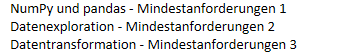

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("survey_results_public.csv", index_col="ResponseId")
df = df.drop(columns=df.columns[df.columns.str.startswith('SO')])
df["EdLevel"] = df["EdLevel"].str.split("(").str[0].str.strip()
df["Country"] = df["Country"].replace({
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "United States of America": "USA",
})
df["EdLevel"] = df["EdLevel"].replace({
    "Some college/university study without earning a degree": "Some college"
})

Je Land wird die Anzahl der jeweiligen Education Level ausgegeben um einen Überblick der Verteilung zu erhalten

In [54]:
table = (
    df.dropna(subset=["Country", "EdLevel"])
      .groupby(["Country", "EdLevel"])
      .size()
      .to_frame("count")
)

table

count
Country     EdLevel                                                  
Afghanistan Bachelor’s degree                                       5
            Master’s degree                                         2
            Primary/elementary school                               1
            Professional degree                                     1
            Secondary school                                        1
...                                                               ...
Zambia      Secondary school                                        1
            Some college/university study without earning a...      2
Zimbabwe    Bachelor’s degree                                       7
            Master’s degree                                         4
            Some college/university study without earning a...      2

[903 rows x 1 columns]

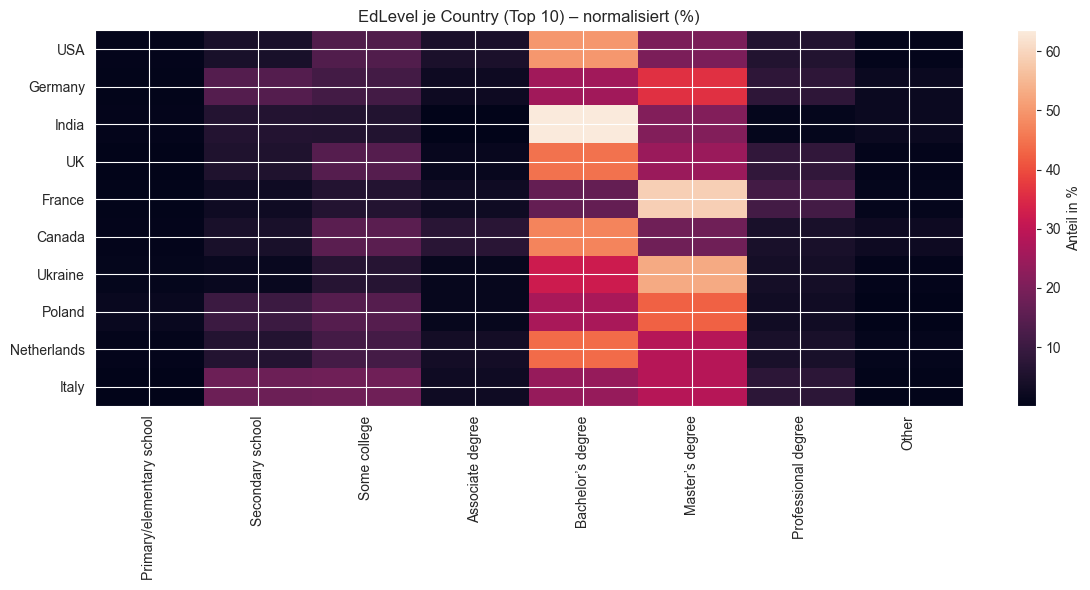

In [55]:
import matplotlib.pyplot as plt

wide = table.reset_index().pivot(index="Country", columns="EdLevel", values="count").fillna(0)

TOP_N = 10
plot_df = wide.loc[wide.sum(axis=1).sort_values(ascending=False).head(TOP_N).index]

# Spalten sinnvoll sortieren (nur die, die wirklich vorhanden sind)
desired_order = [
    "Primary/elementary school",
    "Secondary school",
    "Some college",
    "Associate degree",
    "Bachelor’s degree",
    "Master’s degree",
    "Professional degree",
    "Other",
]
plot_df = plot_df[[c for c in desired_order if c in plot_df.columns]]

plot_pct = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

# Heatmap
plt.figure(figsize=(12,6))
plt.imshow(plot_pct.values, aspect="auto")
plt.yticks(range(len(plot_pct.index)), plot_pct.index)
plt.xticks(range(len(plot_pct.columns)), plot_pct.columns, rotation=90)
plt.colorbar(label="Anteil in %")
plt.title(f"Education Level je Country (Top {TOP_N}) – normalisiert (%)")
plt.tight_layout()
plt.show()


- durch Normalisierung in Prozent sind Länder besser vergleichbar
- Überall dominieren Bachelor und Master Degrees
- Indien wirkt besonders Bachelorlastig
- europäische Länder wirken Masterlastiger als andere
- USA/Canada zeigen relativ mehr "Some College" als viele europäische Länder
- "Primary/elementary school" und "Associate degree" sind in allen Top-10 nur gering vertreten

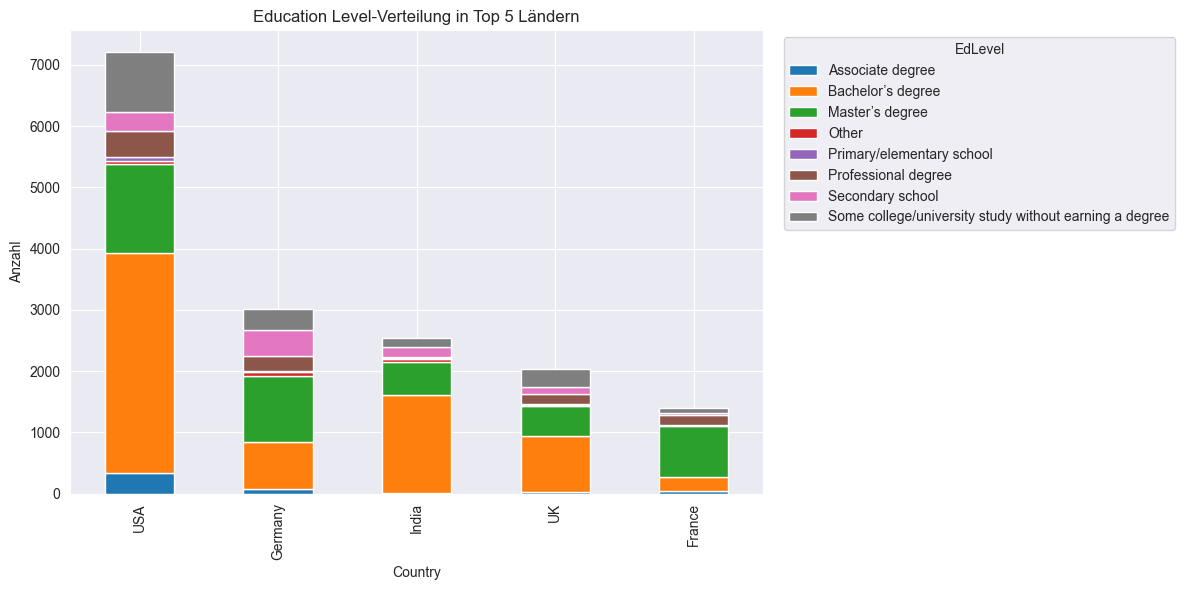

In [62]:
TOP_N_2 = 5
top_countries = wide.sum(axis=1).sort_values(ascending=False).head(TOP_N_2).index
plot_df = wide.loc[top_countries]

ax = plot_df.plot(kind="bar", stacked=True, figsize=(12,6))
ax.set_xlabel("Country")
ax.set_ylabel("Anzahl")
ax.set_title(f"Education Level-Verteilung in Top {TOP_N_2} Ländern")

ax.legend(title="EdLevel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

- Konvertierungstabelle mit Kontinenten zu Ländern erstellen um Verteilung der Education Level zu sehen
- Mapping nur für häufige Länder, Rest -> Other

In [56]:
country_to_continent = pd.DataFrame({
    "Country": [
        "Germany", "UK", "USA", "Canada", "France", "Netherlands", "Spain", "Italy", "Ukraine",
        "India", "China", "Japan",
        "Brazil", "Argentina",
        "Australia", "New Zealand",
        "South Africa"
    ],
    "Continent": [
        "Europe","Europe","North America","North America","Europe","Europe","Europe","Europe","Europe",
        "Asia","Asia","Asia",
        "South America","South America",
        "Oceania","Oceania",
        "Africa"
    ]
})

# Merge (left join, damit alle df-Zeilen erhalten bleiben)
df_merged = df.merge(country_to_continent, on="Country", how="left")

# Unbekannte Länder sammeln
df_merged["Continent"] = df_merged["Continent"].fillna("Other")

df_merged[["Country", "Continent"]].head()


,Country,Continent
0,Ukraine,Europe
1,Netherlands,Europe
2,Ukraine,Europe
3,Ukraine,Europe
4,Ukraine,Europe


In [63]:
pivot_counts = df_merged.pivot_table(
    index="Continent",
    columns="EdLevel",
    aggfunc="size",
    fill_value=0
)

pivot_counts

EdLevel,Associate degree,Bachelor’s degree,Master’s degree,Other,Primary/elementary school,Professional degree,Secondary school,Some college/university study without earning a degree
Continent,,,,,,,,
Africa,7,108,29,9,2,7,28,63
Asia,15,1824,639,52,24,45,183,199
Europe,250,3026,3609,122,56,789,819,1160
North America,429,4217,1683,88,67,476,371,1173
Oceania,25,544,182,17,7,64,70,146
Other,766,10095,6270,401,412,1171,2065,3239
South America,68,433,163,12,14,68,91,195


In [58]:
pivot_share = pivot_counts.div(pivot_counts.sum(axis=1), axis=0) * 100

pivot_share

EdLevel,Associate degree,Bachelor’s degree,Master’s degree,Other,Primary/elementary school,Professional degree,Secondary school,Some college/university study without earning a degree
Continent,,,,,,,,
Africa,2.766798,42.687747,11.462451,3.557312,0.790514,2.766798,11.067194,24.901186
Asia,0.503187,61.187521,21.435760,1.744381,0.805099,1.509561,6.138880,6.675612
Europe,2.542976,30.780185,36.710406,1.240972,0.569627,8.025633,8.330790,11.799410
North America,5.044685,49.588429,19.790687,1.034807,0.787865,5.597366,4.362653,13.793509
Oceania,2.369668,51.563981,17.251185,1.611374,0.663507,6.066351,6.635071,13.838863
Other,3.136902,41.340759,25.676727,1.642164,1.687211,4.795446,8.456530,13.264261
South America,6.513410,41.475096,15.613027,1.149425,1.340996,6.513410,8.716475,18.678161


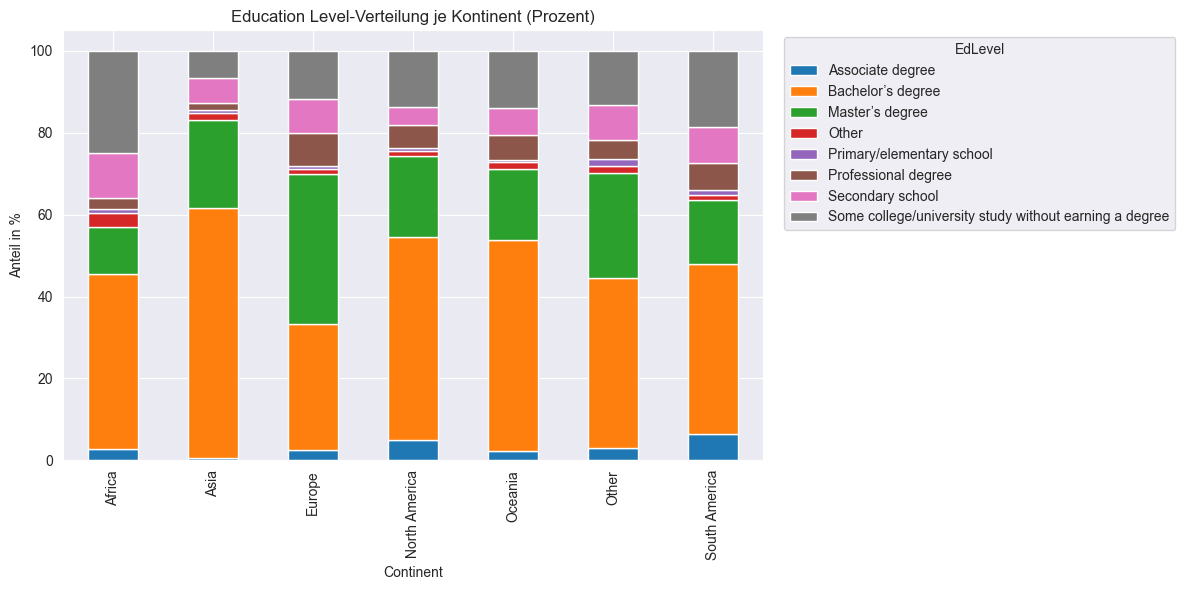

In [61]:
ax = pivot_share.plot(kind="bar", stacked=True, figsize=(12,6))
ax.set_xlabel("Continent")
ax.set_ylabel("Anteil in %")
ax.set_title("Education Level-Verteilung je Kontinent (Prozent)")
ax.legend(title="EdLevel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

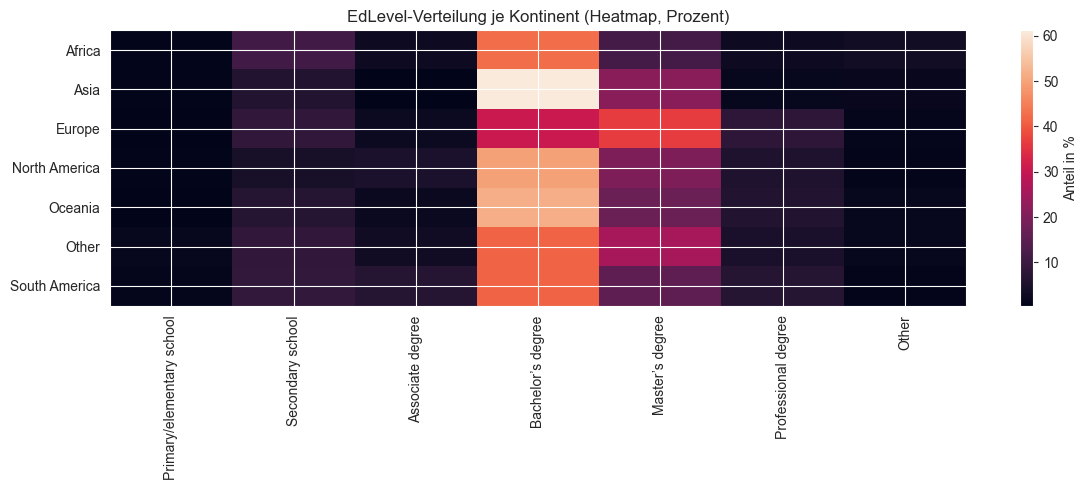

In [64]:
plot_cont = pivot_share.copy()
desired_order = [
    "Primary/elementary school",
    "Secondary school",
    "Some college",
    "Associate degree",
    "Bachelor’s degree",
    "Master’s degree",
    "Professional degree",
    "Other",
]
plot_cont = plot_cont[[c for c in desired_order if c in plot_cont.columns]]

plt.figure(figsize=(12,5))
plt.imshow(plot_cont.values, aspect="auto")
plt.yticks(range(len(plot_cont.index)), plot_cont.index)
plt.xticks(range(len(plot_cont.columns)), plot_cont.columns, rotation=90)
plt.colorbar(label="Anteil in %")
plt.title("EdLevel-Verteilung je Kontinent (Heatmap, Prozent)")
plt.tight_layout()
plt.show()


- die Heatmap zeigt prozentuale EdLevel-Verteilung je Kontinent
- in allen Kontinenten dominieren Bachelor’s degree und Master’s degree höchste Anteile
- Asien besonders Bachelor-lastig, Master dort geringer als in Europa
- Europa hat vergleichsweise hohen Master-Anteil
- Afrika fällt durch relativ hohen Anteil Some college auf d.h. mehr „angefangen, aber kein Abschluss“
- Primary/elementary school und Associate degree sind in allen Kontinenten gering vertreten
